# Figure 7: Vendor and age–QC views

Panels D onward: R²(IQM vs. age), vendor-stratified and pooled; age vs raw_neighbor_corr by vendor; Δ age effect by vendor pair; raw_neighbor_corr effect by vendor; age effect with vs without QC.


## Shared Setup

Libraries, config, plot style, figure directory, theme, and data loading (same as Figure 6).


In [27]:
# --- Libraries ---
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(readr)
  library(stringr)
  library(purrr)
  library(scales)
  library(patchwork)
  library(grid)
})

# --- Config and project paths ---
config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file.exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) {
  stop("Could not locate config.json. Set CONFIG_PATH or run from within the project tree.")
}
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)
plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
plot_style$axis_line_width <- 0.35
plot_style$axis_tick_width <- 0.35
figure7_dir <- fs::path(project_root, "figures", "Figure7")
fs::dir_create(figure7_dir, recurse = TRUE)
font_family_use <- get_export_font_family()

# --- Figure layout (panel dimensions for saving) ---
figure_width_mm <- 180
figure_width_in <- figure_width_mm / 25.4
panel_width_mm <- 88
panel_height_in <- (panel_width_mm / 25.4) * 0.96
heatmap_height_scale <- 0.47
heat_height_in <- panel_height_in * heatmap_height_scale
top_row_height_in <- 3.35
figure_height_in <- top_row_height_in + heat_height_in

# --- Panel theme helper (uses plot_style + font) ---
make_panel_theme <- function(legend_position = "none") {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = 6,
    axis_text_pt = 5,
    plot_title_pt = 7,
    legend_title_pt = 5,
    legend_text_pt = 5,
    base_size_pt = 10
  ) +
    theme(text = element_text(family = font_family_use))
}
# save_plot_outputs from plot_style.R (out_dir = figure7_dir)

# --- Microstructural metrics and display labels ---
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")
metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)
metric_order <- c("MKT", "ICVF", "RTOP", "FA", "MD")

# --- IQM (image quality metric) list and family/display helpers ---
iqm_metrics <- c(
  "raw_neighbor_corr", "raw_masked_neighbor_corr",
  "raw_dwi_contrast", "raw_num_bad_slices",
  "raw_coherence_index", "raw_incoherence_index",
  "t1_neighbor_corr", "t1_masked_neighbor_corr",
  "t1_dwi_contrast", "t1_num_bad_slices",
  "t1_coherence_index", "t1_incoherence_index",
  "t1post_neighbor_corr", "t1post_masked_neighbor_corr",
  "t1post_dwi_contrast", "t1post_num_bad_slices",
  "t1post_coherence_index", "t1post_incoherence_index",
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation", "t1_dice_distance",
  "CNR0_mean", "CNR1_mean", "CNR2_mean", "CNR3_mean", "CNR4_mean",
  "CNR0_median", "CNR1_median", "CNR2_median", "CNR3_median", "CNR4_median",
  "CNR0_standard_deviation", "CNR1_standard_deviation", "CNR2_standard_deviation",
  "CNR3_standard_deviation", "CNR4_standard_deviation"
)
motion_iqms <- c(
  "mean_fd", "max_fd", "max_rotation", "max_translation",
  "max_rel_rotation", "max_rel_translation"
)
classify_family <- function(iqm) {
  if (iqm == "t1_dice_distance") return("Coregistration")
  if (iqm %in% motion_iqms) return("Motion")
  if (str_detect(iqm, "^CNR[0-4]_")) return("tSNR/CNR")
  if (str_detect(iqm, "neighbor_corr")) return("Neighbor Corr")
  if (str_detect(iqm, "dwi_contrast")) return("dMRI Contrast")
  if (str_detect(iqm, "num_bad_slices")) return("Bad Slices")
  if (str_detect(iqm, "coherence_index") || str_detect(iqm, "incoherence_index")) return("Coherence/Incoherence")
  "Other"
}

cnr_shell_label <- function(shell_id) {
  switch(
    shell_id,
    "0" = "tSNR (b=0)",
    "1" = "CNR (b=500)",
    "2" = "CNR (b=1000)",
    "3" = "CNR (b=2000)",
    "4" = "CNR (b=3000)",
    "CNR"
  )
}

format_iqm_label <- function(iqm) {
  if (iqm == "t1_dice_distance") return("dMRI-T1w Coregistration")
  if (iqm %in% c("mean_fd", "max_fd", "max_rotation", "max_translation", "max_rel_rotation", "max_rel_translation")) {
    name_map <- c(
      "mean_fd" = "Mean Framewise Displacement",
      "max_fd" = "Max Framewise Displacement",
      "max_rotation" = "Max Rotation",
      "max_translation" = "Max Translation",
      "max_rel_rotation" = "Max Relative Rotation (Derivative)",
      "max_rel_translation" = "Max Relative Translation (Derivative)"
    )
    return(unname(name_map[[iqm]]))
  }
  if (str_detect(iqm, "^CNR[0-4]_(mean|median|standard_deviation)$")) {
    shell_id <- str_match(iqm, "^CNR([0-4])_")[, 2]
    stat <- str_match(iqm, "^(?:CNR[0-4]_)(mean|median|standard_deviation)$")[, 2]
    stat_label <- recode(stat, mean = "Mean", median = "Median", standard_deviation = "SD")
    return(paste(cnr_shell_label(shell_id), stat_label))
  }
  prefix <- case_when(
    str_starts(iqm, "raw_") ~ "Raw",
    str_starts(iqm, "t1post_") ~ "Preprocessed (post-B1)",
    str_starts(iqm, "t1_") ~ "Preprocessed (pre-B1)",
    TRUE ~ ""
  )
  base <- iqm %>%
    str_remove("^raw_") %>%
    str_remove("^t1post_") %>%
    str_remove("^t1_")
  is_masked <- str_starts(base, "masked_")
  core_base <- if (is_masked) str_remove(base, "^masked_") else base
  base_label <- case_when(
    core_base == "neighbor_corr" ~ "Neighboring dMRI Correlation",
    core_base == "dwi_contrast" ~ "dMRI Contrast",
    core_base == "num_bad_slices" ~ "Number of Bad Slices",
    core_base == "coherence_index" ~ "Coherence Index",
    core_base == "incoherence_index" ~ "Incoherence Index",
    TRUE ~ core_base
  )
  qualifier_parts <- character(0)
  if (nzchar(prefix)) {
    q <- prefix %>%
      str_replace("Preprocessed \\(post-B1\\)", "Preprocessed, post-B1") %>%
      str_replace("Preprocessed \\(pre-B1\\)", "Preprocessed, pre-B1")
    qualifier_parts <- c(qualifier_parts, q)
  }
  if (is_masked) qualifier_parts <- c(qualifier_parts, "Masked")
  if (length(qualifier_parts) > 0) {
    paste0(base_label, " (", paste(qualifier_parts, collapse = ", "), ")")
  } else {
    base_label
  }
}
family_order <- c(
  "Neighbor Corr",
  "dMRI Contrast",
  "Coherence/Incoherence",
  "Bad Slices",
  "Motion",
  "tSNR/CNR",
  "Coregistration"
)
family_colors <- c(
  "Neighbor Corr" = "#1b9e77",
  "dMRI Contrast" = "#d95f02",
  "Coherence/Incoherence" = "#7570b3",
  "Bad Slices" = "#e7298a",
  "Motion" = "#66a61e",
  "tSNR/CNR" = "#e6ab02",
  "Coregistration" = "#a6761d"
)
# Build lookup: iqm -> pretty label and family for bar chart
iqm_dict <- tibble(iqm = iqm_metrics) %>%
  mutate(
    iqm_label = map_chr(iqm, format_iqm_label),
    family = factor(map_chr(iqm, classify_family), levels = family_order)
  )
# --- Load age–QC effect data (used for winner-take-all and per–QC heatmaps) ---
age_effect_file <- fs::path(project_root, "data", "age_quality_effects", "age_quality_effects_all_outputs.rds")
if (!file.exists(age_effect_file)) stop("Missing assembled age-effect file: ", age_effect_file)
df_age_all <- readRDS(age_effect_file)
required_age_cols <- c(
  "bundle", "bundle_category", "metric", "qc_metric", "source",
  "output_type", "qc_effect_size", "scanner_manufacturer", "age_effect_size"
)
if (!all(required_age_cols %in% names(df_age_all))) {
  stop("Assembled age-effect data missing required columns: ",
       paste(setdiff(required_age_cols, names(df_age_all)), collapse = ", "))
}
# Filter to harmonized non-vendorwise, five metrics, IQM covariates (exclude no_quality/qc_prediction)
df_qc_all <- df_age_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    source == "harmonized",
    metric %in% metrics_keep,
    qc_metric %in% iqm_metrics,
    qc_metric != "qc_prediction",
    !is.na(bundle),
    !is.na(bundle_category),
    !is.na(qc_metric),
    !is.na(qc_effect_size)
  ) %>%
  transmute(
    # Keep bundle, metric, IQM, and QC effect for winner-take-all and heatmaps
    bundle = bundle,
    bundle_category = bundle_category,
    metric = metric,
    metric_label = unname(metric_labels[metric]),
    iqm = qc_metric,
    qc_effect_size = as.numeric(qc_effect_size)
  )
if (nrow(df_qc_all) == 0) {
  stop("No rows found for Figure 7 pooled quality-effects with requested IQMs.")
}


## Panel D: R² of IQM–age association

Bar chart of R² for the association between each IQM and age (from harmonized data). Bars colored by IQM category; ordered by decreasing R² (highest on left). Same dimensions as Panel B. Not added to combined figure.

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_d_iqm_age_r2_bars.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_d_iqm_age_r2_bars.png



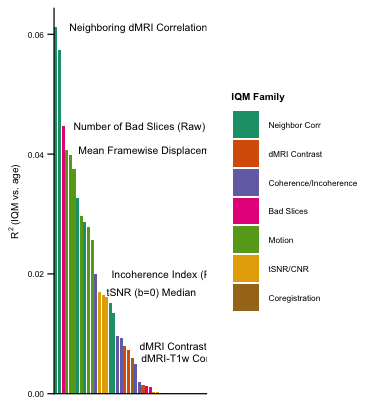

In [28]:
# --- Panel D: R²(IQM vs. age) by IQM, bars colored by category, ranked decreasing R² ---
harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file.exists(harm_path)) stop("Missing harmonized parquet: ", harm_path)
harm_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
iqm_cols <- intersect(iqm_metrics, harm_cols)
if (length(iqm_cols) == 0) stop("No IQM columns found in harmonized parquet")
df_harm <- arrow::read_parquet(harm_path, col_select = c("age", iqm_cols)) %>% as_tibble()
df_harm_long <- df_harm %>%
  tidyr::pivot_longer(all_of(iqm_cols), names_to = "iqm", values_to = "value") %>%
  filter(!is.na(value), !is.na(age))
r2_by_iqm <- df_harm_long %>%
  group_by(iqm) %>%
  summarise(r2_age = cor(age, value, use = "pairwise.complete.obs")^2, .groups = "drop") %>%
  mutate(r2_age = replace_na(r2_age, 0)) %>%
  left_join(iqm_dict, by = "iqm") %>%
  mutate(iqm_label = forcats::fct_reorder(iqm_label, r2_age, .desc = TRUE))
top_per_family <- r2_by_iqm %>% group_by(family) %>% slice_max(order_by = r2_age, n = 1, with_ties = FALSE) %>% ungroup()
p_panel_d <- ggplot(r2_by_iqm, aes(x = iqm_label, y = r2_age, fill = family)) +
  geom_col(width = 0.84) +
  geom_text(
    data = top_per_family,
    aes(x = iqm_label, y = r2_age, label = as.character(iqm_label)),
    inherit.aes = FALSE,
    hjust = -0.08,
    size = 2.2,
    family = font_family_use,
    color = "black"
  ) +
  scale_fill_manual(values = family_colors, drop = TRUE) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
  scale_x_discrete(expand = expansion(add = c(0.5, 2.5))) +
  labs(x = NULL, y = expression(R^2 ~ "(IQM vs. age)"), fill = "IQM Family") +
  make_panel_theme(legend_position = "right") +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(size = 5, color = "black"),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 5)
  )
options(repr.plot.width = figure_width_in * 0.44, repr.plot.height = top_row_height_in, repr.plot.res = 120)
p_panel_d
save_plot_outputs(p_panel_d, "Figure7_panel_d_iqm_age_r2_bars", figure7_dir, figure_width_in * 0.44, top_row_height_in)

## Panel E: R²(age) vs. mean quality effect (FA)

Scatter: each point is one IQM; x = R² of association with age, y = average quality effect in MKT across bundles for that IQM. Points colored by IQM category. Same dimensions as Panel B. Not added to combined figure.

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_e_r2_age_vs_mean_effect_scatter.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_e_r2_age_vs_mean_effect_scatter.png



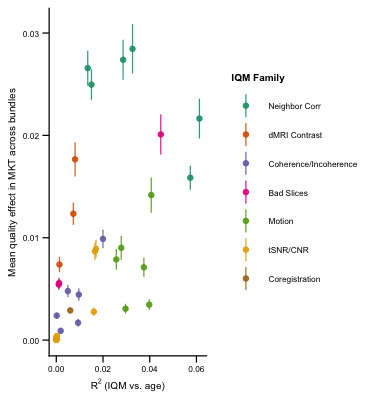

In [29]:
# --- Panel E: scatter R²(IQM vs. age) vs. mean quality effect in MKT across bundles, colored by IQM category ---
mean_effect_by_iqm <- df_qc_all %>%
  filter(metric == "DKI_mkt") %>%
  group_by(iqm) %>%
  summarise(
    n_bundles = n(),
    mean_qc_effect = mean(qc_effect_size, na.rm = TRUE),
    sem_qc_effect = sd(qc_effect_size, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  ) %>%
  mutate(sem_qc_effect = replace_na(sem_qc_effect, 0))
scatter_df <- r2_by_iqm %>%
  select(iqm, r2_age, family, iqm_label) %>%
  left_join(mean_effect_by_iqm, by = "iqm") %>%
  filter(!is.na(mean_qc_effect))
p_panel_e <- ggplot(scatter_df, aes(x = r2_age, y = mean_qc_effect, color = family)) +
  geom_linerange(
    aes(ymin = mean_qc_effect - sem_qc_effect, ymax = mean_qc_effect + sem_qc_effect),
    linewidth = 0.35,
    alpha = 0.9
  ) +
  geom_point(size = 1.2, alpha = 0.9) +
  scale_color_manual(values = family_colors, drop = TRUE) +
  labs(
    x = expression(R^2 ~ "(IQM vs. age)"),
    y = "Mean quality effect in MKT across bundles",
    color = "IQM Family"
  ) +
  make_panel_theme(legend_position = "right") +
  theme(
    panel.grid = element_blank(),
    axis.text = element_text(size = 5, color = "black"),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 5)
  )
options(repr.plot.width = figure_width_in * 0.44, repr.plot.height = top_row_height_in, repr.plot.res = 120)
p_panel_e
save_plot_outputs(p_panel_e, "Figure7_panel_e_r2_age_vs_mean_effect_scatter", figure7_dir, figure_width_in * 0.44, top_row_height_in)

## Panel D2: R²(IQM vs. age) by vendor

Within each scanner vendor, R² between each IQM and age (from harmonized data). Bar chart faceted by vendor; bars colored by IQM family.

In [30]:
# --- Panel D2: R²(IQM vs. age) in each vendor ---
harm_path_d2 <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file.exists(harm_path_d2)) stop("Missing harmonized parquet: ", harm_path_d2)
harm_cols_d2 <- arrow::open_dataset(harm_path_d2, format = "parquet")$schema$names
iqm_cols_d2 <- intersect(iqm_metrics, harm_cols_d2)
if ("scanner_manufacturer" %in% harm_cols_d2 && length(iqm_cols_d2) > 0) {
  df_harm_vendor <- arrow::read_parquet(harm_path_d2, col_select = c("age", "scanner_manufacturer", iqm_cols_d2)) %>%
    as_tibble() %>%
    filter(!is.na(scanner_manufacturer))
  df_harm_vendor_long <- df_harm_vendor %>%
    tidyr::pivot_longer(all_of(iqm_cols_d2), names_to = "iqm", values_to = "value") %>%
    filter(!is.na(value), !is.na(age))
  r2_by_iqm_vendor <- df_harm_vendor_long %>%
    group_by(iqm, scanner_manufacturer) %>%
    summarise(r2_age = cor(age, value, use = "pairwise.complete.obs")^2, .groups = "drop") %>%
    mutate(r2_age = replace_na(r2_age, 0)) %>%
    left_join(iqm_dict, by = "iqm")
  r2_pooled <- df_harm_vendor_long %>%
    group_by(iqm) %>%
    summarise(r2_age = cor(age, value, use = "pairwise.complete.obs")^2, .groups = "drop") %>%
    mutate(r2_age = replace_na(r2_age, 0), scanner_manufacturer = "Pooled") %>%
    left_join(iqm_dict, by = "iqm")
  vendor_levels <- sort(unique(as.character(r2_by_iqm_vendor$scanner_manufacturer)))
  r2_combined <- bind_rows(r2_by_iqm_vendor, r2_pooled) %>%
    mutate(scanner_manufacturer = factor(scanner_manufacturer, levels = c(vendor_levels, "Pooled"))) %>%
    group_by(scanner_manufacturer) %>%
    arrange(desc(r2_age), .by_group = TRUE) %>%
    mutate(rank = row_number()) %>%
    ungroup()
  iqm_arrows <- c("raw_neighbor_corr", "t1post_neighbor_corr", "raw_dwi_contrast", "t1post_dwi_contrast")
  arrow_labels <- c("Raw neighbor corr", "Preprocessed neighbor corr", "Raw dMRI contrast", "Preprocessed dMRI contrast")
  arrow_colors <- setNames(c("#1b9e77", "#1b9e77", "#d95f02", "#d95f02"), arrow_labels)
  arrow_lt <- setNames(c("solid", "dotted", "solid", "dotted"), arrow_labels)
  ymax_by_facet <- r2_combined %>% group_by(scanner_manufacturer) %>% summarise(ymax = max(r2_age, na.rm = TRUE), .groups = "drop")
  arrow_d2 <- r2_combined %>%
    filter(iqm %in% iqm_arrows) %>%
    left_join(ymax_by_facet, by = "scanner_manufacturer") %>%
    mutate(
      y_start = r2_age + 0.07 * ymax,
      y_mid = r2_age + 0.01 * ymax,
      arrow_label = factor(arrow_labels[match(iqm, iqm_arrows)], levels = arrow_labels)
    )
  p_panel_d2 <- ggplot(r2_combined, aes(x = rank, y = r2_age, fill = family)) +
    geom_col(width = 0.84) +
    geom_segment(
      data = arrow_d2,
      aes(x = rank, xend = rank, y = y_start, yend = y_mid, color = arrow_label, linetype = arrow_label),
      linewidth = 0.5
    ) +
    geom_segment(
      data = arrow_d2,
      aes(x = rank, xend = rank, y = y_mid, yend = r2_age, color = arrow_label),
      linetype = "solid",
      arrow = grid::arrow(length = grid::unit(0.05, "inch"), type = "open"),
      linewidth = 0.5,
      show.legend = FALSE
    ) +
    scale_color_manual(name = "Arrow", values = arrow_colors) +
    scale_linetype_manual(name = "Arrow", values = arrow_lt) +
    scale_fill_manual(values = family_colors, drop = TRUE) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
    facet_wrap(~ scanner_manufacturer, ncol = 2, scales = "free_y") +
    labs(x = NULL, y = expression(R^2 ~ "(IQM vs. age)"), fill = "IQM Family") +
    make_panel_theme(legend_position = "right") +
    theme(
      panel.grid = element_blank(),
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.text.y = element_text(size = 5, color = "black"),
      strip.text = element_text(size = 6),
      legend.title = element_text(size = 6),
      legend.text = element_text(size = 5)
    )
  options(repr.plot.width = figure_width_in * 0.9, repr.plot.height = 4, repr.plot.res = 120)
  p_panel_d2
  save_plot_outputs(p_panel_d2, "Figure7_panel_d2_iqm_age_r2_by_vendor", figure7_dir, figure_width_in * 0.9, 4)
} else {
  message("Panel D2: scanner_manufacturer not in harmonized parquet or no IQM columns. Skip R² by vendor.")
}

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_d2_iqm_age_r2_by_vendor.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_d2_iqm_age_r2_by_vendor.png



## Plot 2a: Age vs raw_neighbor_corr in GE scanners (points colored by scanner software, shaped by site)

GE only: X = Age, Y = raw_neighbor_corr. Points are colored by scanner software and shaped by site, with GAM smooths fit per scanner software (colored by scanner software).

In [31]:
# --- Plot 2a: Age vs raw_neighbor_corr in GE scanners, points colored by scanner software and shaped by site, with software-wise GAM smooths ---
if (requireNamespace("mgcv", quietly = TRUE)) suppressPackageStartupMessages(library(mgcv))
harm_plot2a <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (file.exists(harm_plot2a)) {
  harm_schema <- arrow::open_dataset(harm_plot2a, format = "parquet")$schema$names
  required_plot2a <- c("age", "scanner_manufacturer", "raw_neighbor_corr", "site", "scanner_software")
  if (all(required_plot2a %in% harm_schema)) {
    df_plot2a <- arrow::read_parquet(harm_plot2a, col_select = required_plot2a) %>%
      as_tibble() %>%
      mutate(scanner_manufacturer = as.character(scanner_manufacturer)) %>%
      filter(scanner_manufacturer == "GE") %>%
      filter(!is.na(site), !is.na(scanner_software), !is.na(age), !is.na(raw_neighbor_corr))
    if (nrow(df_plot2a) > 0) {
      site_levels <- sort(unique(as.character(df_plot2a$site)))
      software_levels <- sort(unique(as.character(df_plot2a$scanner_software)))
      df_plot2a <- df_plot2a %>% mutate(
        site = factor(as.character(site), levels = site_levels),
        scanner_software = factor(as.character(scanner_software), levels = software_levels)
      )
      software_colors <- setNames(scales::hue_pal()(length(software_levels)), software_levels)
      site_shapes <- setNames(scales::shape_pal()(length(site_levels)), site_levels)
      p_plot2a <- ggplot(df_plot2a, aes(x = age, y = raw_neighbor_corr)) +
      geom_point(aes(color = scanner_software, shape = site), alpha = 0.35, size = 0.8) +
      geom_smooth(aes(color = scanner_software, group = scanner_software), method = "gam", formula = y ~ s(x, bs = "cs"), se = FALSE, linewidth = 0.8, alpha = 0.9) +
      scale_color_manual(values = software_colors, name = "Scanner software") +
      scale_shape_manual(values = site_shapes, name = "Site") +
      labs(x = "Age", y = "raw_neighbor_corr", title = "GE scanners") +
      make_panel_theme(legend_position = "right") +
      theme(
        panel.grid = element_blank(),
        axis.text = element_text(size = 5, color = "black"),
        legend.title = element_text(size = 6),
        legend.text = element_text(size = 5)
      )
      options(repr.plot.width = figure_width_in * 0.9, repr.plot.height = 4, repr.plot.res = 120)
      p_plot2a
      save_plot_outputs(p_plot2a, "Figure7_plot2a_age_vs_raw_neighbor_corr_ge_by_software_site", figure7_dir, figure_width_in * 0.9, 4)
    } else {
      message("Plot 2a: No GE rows with non-missing age, raw_neighbor_corr, site, and scanner_software.")
    }
  } else {
    message("Plot 2a: harmonized parquet missing required columns: ", paste(setdiff(required_plot2a, harm_schema), collapse = ", "))
  }
} else {
  message("Plot 2a: Missing harmonized parquet: ", harm_plot2a)
}

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_plot2a_age_vs_raw_neighbor_corr_by_vendor.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_plot2a_age_vs_raw_neighbor_corr_by_vendor.png



## Plot 2b: Δ (age effect with QC − without QC) by vendor pair

For each bundle: Δ_vendor = (age effect with QC − age effect without QC). For each vendor pair: scatter Δ_vendor1 vs Δ_vendor2 (one point per bundle). Identity line. Facet by metric (FA, MKT).

In [32]:
# --- Plot 2b: Delta age-effect (with QC − without QC) by vendor pair, scatter, facet by metric ---
# Age effect = age_effect_size (R² improvement from age). With/without QC from raw_neighbor_corr vs no_quality. Join and compute delta.
metrics_plot2b <- c("GQI_fa", "DKI_mkt")
age_with_qc <- df_age_all %>%
  filter(
    output_type == "vendorwise_pairwise",
    qc_metric == "raw_neighbor_corr",
    metric %in% metrics_plot2b,
    source == "harmonized",
    !is.na(scanner_manufacturer),
    !is.na(age_effect_size)
  ) %>%
  select(bundle, bundle_category, metric, scanner_manufacturer, age_effect_with_qc = age_effect_size)
age_no_qc <- df_age_all %>%
  filter(
    output_type == "vendorwise_pairwise",
    qc_metric == "no_quality",
    metric %in% metrics_plot2b,
    source == "harmonized",
    !is.na(scanner_manufacturer),
    !is.na(age_effect_size)
  ) %>%
  select(bundle, metric, scanner_manufacturer, age_effect_no_qc = age_effect_size)
df_delta <- age_with_qc %>%
  left_join(age_no_qc, by = c("bundle", "metric", "scanner_manufacturer")) %>%
  filter(!is.na(age_effect_no_qc)) %>%
  mutate(
    delta_b = as.numeric(age_effect_with_qc) - as.numeric(age_effect_no_qc),
    metric_label = factor(unname(metric_labels[metric]), levels = c("FA", "MKT"))
  ) %>%
  select(bundle, bundle_category, metric, metric_label, scanner_manufacturer, delta_b)

if (nrow(df_delta) > 0) {
  vendors <- sort(unique(as.character(df_delta$scanner_manufacturer)))
  vendor_pairs <- if (length(vendors) >= 2) {
    t(combn(vendors, 2))
  } else {
    matrix(character(0), ncol = 2)
  }
  delta_wide <- df_delta %>%
    select(bundle, metric, metric_label, scanner_manufacturer, delta_b) %>%
    tidyr::pivot_wider(names_from = scanner_manufacturer, values_from = delta_b)
  scatter_list <- list()
  for (i in seq_len(nrow(vendor_pairs))) {
    v1 <- vendor_pairs[i, 1]
    v2 <- vendor_pairs[i, 2]
    if (!v1 %in% names(delta_wide) || !v2 %in% names(delta_wide)) next
    d <- delta_wide %>%
      filter(!is.na(.data[[v1]]), !is.na(.data[[v2]])) %>%
      mutate(vendor1 = v1, vendor2 = v2, x_val = .data[[v1]], y_val = .data[[v2]])
    scatter_list[[length(scatter_list) + 1]] <- d
  }
  df_scatter <- bind_rows(scatter_list)
  if (nrow(df_scatter) > 0) {
    df_scatter <- df_scatter %>%
      mutate(vendor_pair = paste(vendor1, "vs", vendor2))
    p_plot2b <- ggplot(df_scatter, aes(x = x_val, y = y_val)) +
      geom_abline(slope = 1, intercept = 0, color = "grey50", linewidth = 0.4, linetype = "dashed") +
      geom_point(alpha = 0.8, size = 1.5) +
      facet_grid(metric_label ~ vendor_pair, scales = "free") +
      labs(
        x = expression(Delta ~ "(age effect with QC - without QC), vendor 1"),
        y = expression(Delta ~ "(vendor 2)"),
        title = "Δ age effect by vendor pair (each point = bundle)"
      ) +
      make_panel_theme(legend_position = "none") +
      theme(
        panel.grid = element_blank(),
        axis.text = element_text(size = 5, color = "black"),
        strip.text = element_text(size = 6)
      )
    options(repr.plot.width = figure_width_in * 0.9, repr.plot.height = 5, repr.plot.res = 120)
    p_plot2b
    save_plot_outputs(p_plot2b, "Figure7_plot2b_delta_b_vendor_pair_scatter", figure7_dir, figure_width_in * 0.9, 5)
  } else {
    message("Plot 2b: No complete vendor-pair rows after pivot.")
  }
} else {
  message("Plot 2b: No vendorwise raw_neighbor_corr + no_quality data (or no complete joins). Run age-quality effects vendorwise for no_quality and raw_neighbor_corr (FA and MKT), then reassemble.")
}

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_plot2b_delta_b_vendor_pair_scatter.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_plot2b_delta_b_vendor_pair_scatter.png



## Panel F: Effect of adding raw_neighbor_corr as covariate, by vendor (FA and MKT)

Within each vendor, for each bundle and metric (FA, MKT): percent change in predicted bundle value when going from 10th to 90th percentile of raw_neighbor_corr. Positive = higher raw_neighbor_corr is associated with higher bundle value; negative = lower. Heatmap: rows = bundles, columns = vendor, faceted by metric.

In [33]:
# --- Panel F: raw_neighbor_corr effect on bundle values within vendor, FA and MKT ---
if (!exists("prettify_bundle")) prettify_bundle <- function(x) stringr::str_replace_all(as.character(x), "_", " ")
df_neighbor_vendor <- df_age_all %>%
  filter(
    output_type == "vendorwise_pairwise",
    qc_metric == "raw_neighbor_corr",
    metric %in% c("GQI_fa", "DKI_mkt"),
    source == "harmonized",
    !is.na(scanner_manufacturer)
  )
use_pct <- nrow(df_neighbor_vendor) > 0 && "percent_change_qc" %in% names(df_neighbor_vendor)
if (nrow(df_neighbor_vendor) > 0) {
  df_neighbor_vendor <- df_neighbor_vendor %>%
    mutate(
      bundle_clean = dplyr::coalesce(prettify_bundle(as.character(bundle)), as.character(bundle)),
      metric_label = factor(unname(metric_labels[metric]), levels = c("FA", "MKT")),
      scanner_manufacturer = as.character(scanner_manufacturer),
      fill_val = if (use_pct) as.numeric(percent_change_qc) else as.numeric(qc_effect_size)
    )
  bundle_order <- df_neighbor_vendor %>%
    distinct(bundle_category, bundle, bundle_clean) %>%
    arrange(bundle_category, bundle) %>%
    pull(bundle_clean)
  df_neighbor_vendor <- df_neighbor_vendor %>%
    mutate(bundle_clean = factor(bundle_clean, levels = rev(unique(bundle_order))))
  p_panel_f <- ggplot(df_neighbor_vendor, aes(x = scanner_manufacturer, y = bundle_clean, fill = fill_val)) +
    geom_tile(color = "grey85", linewidth = 0.25) +
    facet_wrap(~ metric_label, ncol = 2, strip.position = "top") +
    labs(x = "Vendor", y = "Bundle") +
    make_panel_theme(legend_position = "right") +
    theme(
      panel.grid = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, size = 5, color = "black"),
      axis.text.y = element_text(size = 4, color = "black"),
      strip.text = element_text(size = 6),
      legend.title = element_text(size = 6),
      legend.text = element_text(size = 5)
    )
  if (use_pct) {
    p_panel_f <- p_panel_f +
      scale_fill_gradient2(
        low = "#2166ac", mid = "white", high = "#b2182b",
        midpoint = 0, na.value = "grey90",
        name = "% change (10th→90th pctl)"
      ) +
      labs(title = "Effect of raw_neighbor_corr on bundle value (within vendor)")
  } else {
    p_panel_f <- p_panel_f +
      scale_fill_viridis_c(option = "plasma", name = expression(Delta * R^2)) +
      labs(title = "Effect of raw_neighbor_corr (ΔR², within vendor)")
  }
  panel_f_height_in <- 5
  options(repr.plot.width = figure_width_in * 0.9, repr.plot.height = panel_f_height_in, repr.plot.res = 120)
  p_panel_f
  save_plot_outputs(p_panel_f, "Figure7_panel_f_raw_neighbor_corr_by_vendor", figure7_dir, figure_width_in * 0.9, panel_f_height_in)
} else {
  message("Panel F: No vendorwise raw_neighbor_corr data. Run age-quality effects vendorwise for raw_neighbor_corr (FA and MKT) and reassemble.")
}


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_f_raw_neighbor_corr_by_vendor.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_f_raw_neighbor_corr_by_vendor.png



## Panel G: Age effect without QC vs with QC (FA and MKT; raw_neighbor_corr and t1post_dwi_contrast)

Uses `age_quality_effects_all_outputs.rds`: **X** = age effect without quality covariate (age_effect_size from no_quality model); **Y** = age effect with quality covariate (age_effect_size from full model for that IQM). Each point = one bundle. Identity line (y = x). **Color** = quality effect (qc_effect_size). Shape by bundle category. Facet by vendor, micro metric, and QC metric.

In [34]:
# --- Panel G: Age effect without QC vs age effect with QC; color = quality effect ---
# X = age effect from no_quality model; Y = age effect from full model (with that IQM); color = qc_effect_size.
qc_for_scatter <- c("raw_neighbor_corr", "t1post_dwi_contrast")
metrics_for_scatter <- c("GQI_fa", "DKI_mkt")

# Age effect from no_quality model (per bundle, metric, vendor)
age_no_qc <- df_age_all %>%
  filter(
    output_type == "vendorwise_pairwise",
    qc_metric == "no_quality",
    metric %in% metrics_for_scatter,
    source == "harmonized",
    !is.na(scanner_manufacturer)
  ) %>%
  select(bundle, bundle_category, metric, scanner_manufacturer, age_effect_no_qc = age_effect_size)

# Per IQM: age effect (with QC) and QC effect (per bundle, metric, vendor, qc_metric)
df_iqm <- df_age_all %>%
  filter(
    output_type == "vendorwise_pairwise",
    metric %in% metrics_for_scatter,
    qc_metric %in% qc_for_scatter,
    source == "harmonized",
    !is.na(scanner_manufacturer)
  ) %>%
  select(bundle, bundle_category, metric, scanner_manufacturer, qc_metric, age_effect_with_qc = age_effect_size, qc_effect_size)

df_age_slope <- df_iqm %>%
  left_join(age_no_qc, by = c("bundle", "bundle_category", "metric", "scanner_manufacturer")) %>%
  filter(!is.na(age_effect_no_qc), !is.na(age_effect_with_qc)) %>%
  mutate(
    age_effect_no_qc = as.numeric(age_effect_no_qc),
    age_effect_with_qc = as.numeric(age_effect_with_qc),
    qc_effect_size = as.numeric(qc_effect_size),
    metric_label = factor(unname(metric_labels[metric]), levels = c("FA", "MKT")),
    qc_label = factor(
      dplyr::recode(qc_metric, raw_neighbor_corr = "Raw dMRI Neighbor Corr.", t1post_dwi_contrast = "Preprocessed dMRI Contrast"),
      levels = c("Raw dMRI Neighbor Corr.", "Preprocessed dMRI Contrast")
    ),
    bundle_category = as.character(bundle_category)
  )

# Pooled (non-vendorwise) harmonized: age effect no QC and per IQM
age_no_qc_pooled <- df_age_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    qc_metric == "no_quality",
    metric %in% metrics_for_scatter,
    source == "harmonized"
  ) %>%
  select(bundle, bundle_category, metric, age_effect_no_qc = age_effect_size)
df_iqm_pooled <- df_age_all %>%
  filter(
    output_type == "non_vendorwise_pairwise",
    metric %in% metrics_for_scatter,
    qc_metric %in% qc_for_scatter,
    source == "harmonized"
  ) %>%
  select(bundle, bundle_category, metric, qc_metric, age_effect_with_qc = age_effect_size, qc_effect_size)
df_pooled <- df_iqm_pooled %>%
  left_join(age_no_qc_pooled, by = c("bundle", "bundle_category", "metric")) %>%
  filter(!is.na(age_effect_no_qc), !is.na(age_effect_with_qc)) %>%
  mutate(
    scanner_manufacturer = "Pooled",
    age_effect_no_qc = as.numeric(age_effect_no_qc),
    age_effect_with_qc = as.numeric(age_effect_with_qc),
    qc_effect_size = as.numeric(qc_effect_size),
    metric_label = factor(unname(metric_labels[metric]), levels = c("FA", "MKT")),
    qc_label = factor(
      dplyr::recode(qc_metric, raw_neighbor_corr = "Raw dMRI Neighbor Corr.", t1post_dwi_contrast = "Preprocessed dMRI Contrast"),
      levels = c("Raw dMRI Neighbor Corr.", "Preprocessed dMRI Contrast")
    ),
    bundle_category = as.character(bundle_category)
  )

if (nrow(df_age_slope) > 0 || nrow(df_pooled) > 0) {
  df_age_slope <- dplyr::bind_rows(df_age_slope, df_pooled)
  vendor_levels <- c(sort(setdiff(unique(df_age_slope$scanner_manufacturer), "Pooled")), "Pooled")
  df_age_slope <- df_age_slope %>% mutate(scanner_manufacturer = factor(scanner_manufacturer, levels = vendor_levels))
  n_cat <- n_distinct(df_age_slope$bundle_category)
  shape_vals <- setNames(
    c(16, 17, 15, 18, 8, 3, 4, 7)[seq_len(n_cat)],
    sort(unique(df_age_slope$bundle_category))
  )
  qc_raw <- "Raw dMRI Neighbor Corr."
  qc_preproc <- "Preprocessed dMRI Contrast"
  d_fa_raw <- dplyr::filter(df_age_slope, metric_label == "FA", qc_label == qc_raw)
  d_fa_pre <- dplyr::filter(df_age_slope, metric_label == "FA", qc_label == qc_preproc)
  d_mkt_raw <- dplyr::filter(df_age_slope, metric_label == "MKT", qc_label == qc_raw)
  d_mkt_pre <- dplyr::filter(df_age_slope, metric_label == "MKT", qc_label == qc_preproc)
  lim_cell <- function(d) range(c(d$age_effect_no_qc, d$age_effect_with_qc), na.rm = TRUE)
  lim_fa_raw <- lim_cell(d_fa_raw)
  lim_fa_pre <- lim_cell(d_fa_pre)
  lim_mkt_raw <- lim_cell(d_mkt_raw)
  lim_mkt_pre <- lim_cell(d_mkt_pre)
  lim_qc <- range(df_age_slope$qc_effect_size, na.rm = TRUE)
  p_cell <- function(d, lim, title, lim_qc) {
    if (nrow(d) == 0) return(ggplot() + theme_void())
    rho_df <- d %>%
      group_by(scanner_manufacturer) %>%
      summarise(
        rho = cor(age_effect_no_qc, age_effect_with_qc, method = "spearman", use = "pairwise.complete.obs"),
        .groups = "drop"
      ) %>%
      mutate(
        label = paste0("ρ = ", ifelse(is.na(rho), "NA", round(rho, 2))),
        x = lim[2] - 0.02 * diff(lim),
        y = lim[1] + 0.98 * diff(lim)
      )
    ggplot(d, aes(x = age_effect_no_qc, y = age_effect_with_qc, color = qc_effect_size, shape = bundle_category)) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40", linewidth = 0.35) +
      geom_point(size = 2, alpha = 0.85, stroke = 0.3) +
      geom_text(data = rho_df, aes(x = x, y = y, label = label), inherit.aes = FALSE, hjust = 1, vjust = 1, size = 2.2) +
      scale_color_viridis_c(option = "plasma", name = "QC effect", limits = lim_qc) +
      scale_shape_manual(values = shape_vals, name = "Bundle category", drop = FALSE) +
      scale_x_continuous(limits = lim) +
      scale_y_continuous(limits = lim) +
      facet_wrap(~ scanner_manufacturer, nrow = 2, ncol = 2) +
      labs(x = NULL, y = NULL, title = title) +
      make_panel_theme(legend_position = "right") +
      theme(
        panel.grid = element_blank(),
        axis.text = element_text(size = 5, color = "black"),
        strip.text = element_text(size = 5.5),
        legend.title = element_text(size = 6),
        legend.text = element_text(size = 5)
      )
  }
  p_fa_raw <- p_cell(d_fa_raw, lim_fa_raw, paste("FA", qc_raw, sep = " \u00b7 "), lim_qc) +
    theme(axis.title.x = element_blank())
  p_fa_pre <- p_cell(d_fa_pre, lim_fa_pre, paste("FA", qc_preproc, sep = " \u00b7 "), lim_qc) +
    theme(axis.title.x = element_blank(), axis.title.y = element_blank())
  p_mkt_raw <- p_cell(d_mkt_raw, lim_mkt_raw, paste("MKT", qc_raw, sep = " \u00b7 "), lim_qc) +
    labs(x = "Age effect (without QC covariate)", y = "Age effect (with QC covariate)")
  p_mkt_pre <- p_cell(d_mkt_pre, lim_mkt_pre, paste("MKT", qc_preproc, sep = " \u00b7 "), lim_qc) +
    theme(axis.title.y = element_blank())
  p_panel_g <- (p_fa_raw | p_fa_pre) / (p_mkt_raw | p_mkt_pre) +
    patchwork::plot_layout(guides = "collect") +
    patchwork::plot_annotation(
      theme = theme(
        plot.title = element_text(size = 8, hjust = 0.5)
      )
    )
  panel_g_width_in <- 7
  panel_g_height_in <- 5
  options(repr.plot.width = panel_g_width_in, repr.plot.height = panel_g_height_in, repr.plot.res = 120)
  p_panel_g
  save_plot_outputs(p_panel_g, "Figure7_panel_g_age_effect_vs_qc_effect", figure7_dir, panel_g_width_in, panel_g_height_in)
} else {
  message("Panel G: No vendorwise or pooled rows with no_quality and IQM data. Run age-quality effects (vendorwise and non-vendorwise) for no_quality plus raw_neighbor_corr and t1post_dwi_contrast (FA and MKT), then reassemble.")
}

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_g_age_effect_vs_qc_effect.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure7/Figure7_panel_g_age_effect_vs_qc_effect.png

